# Dynamic Pricing - Sızıntısız Modelleme (Leakage-Free)
Bu notebook'ta Random Forest modelinin veri sızıntısı (data leakage) içermeyen bir versiyonu oluşturulmaktadır. Modelin ezberlemesini önlemek için doğrudan hedefe giden değişkenler dışarıda bırakılmıştır.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Uyar?lar? kapatma
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Casper\\.matplotlib\\fontlist-v390.json.matplotlib-lock'


## 1. Veri Yükleme ve Sütun İsimlerini Temizleme

In [2]:
# Veri yükleme
df = pd.read_csv('../data/retail_sales_dataset.csv')

# Sütun isimlerini pythonik hale getirme (snake_case)
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]

# Eksik verileri temizleme
df = df.dropna()

# Tarih işleme
df['date'] = pd.to_datetime(df['date'])
df.head()

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 2. Keşifsel Veri Analizi (EDA)

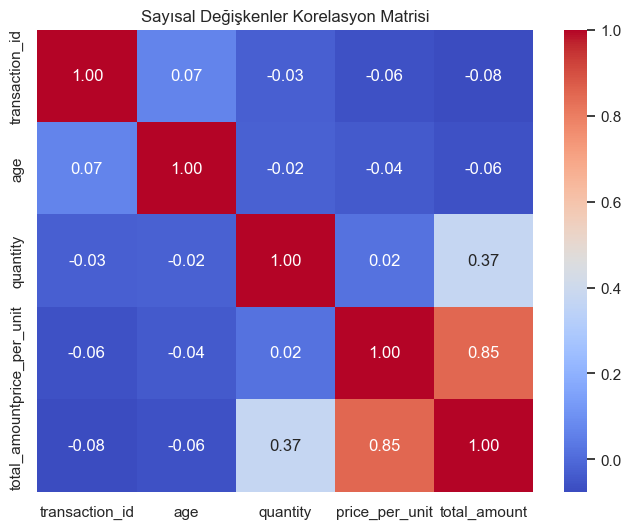

In [3]:
# Sayısal değişkenler için korelasyon matrisi
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Sayısal Değişkenler Korelasyon Matrisi')
plt.show()

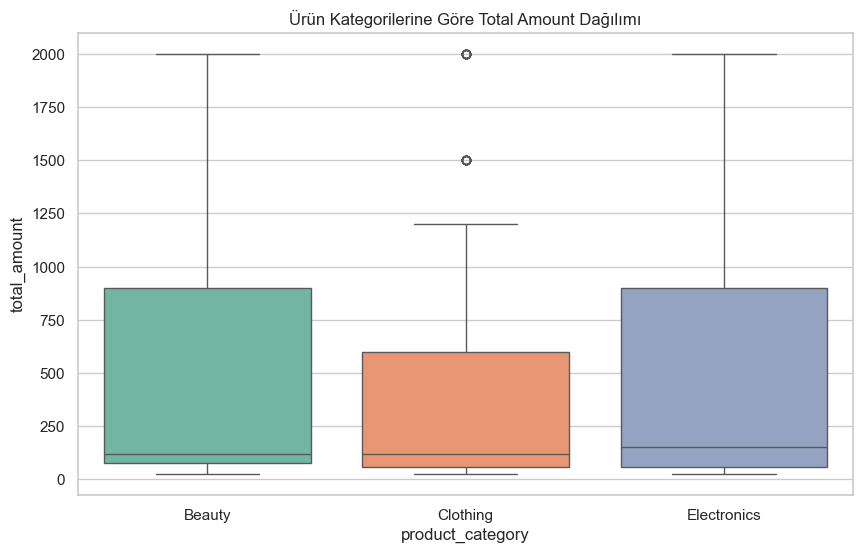

In [4]:
# Kategorilere Göre Total Amount Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='product_category', y='total_amount', data=df, palette='Set2')
plt.title('Ürün Kategorilerine Göre Total Amount Dağılımı')
plt.show()

## 3. Özellik Mühendisliği (Feature Engineering)
Bu aşamada zaman ve demografi tabanlı özellikler üretilecek. Sızıntı yapabilecek özelliklerden kaçınılacak.

In [5]:
# Zaman özellikleri
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Demografik özellikler
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 50, 100], labels=['18-25', '26-35', '36-50', '51+'])

# Sızıntısız Kategori Özelliği
df['category_quantity_mean'] = df.groupby('product_category')['quantity'].transform('mean')

# Kategorikleri encode et
df_model = pd.get_dummies(df, columns=['gender', 'product_category', 'age_group'], drop_first=True)

## 4. Veri Sızıntısı (Data Leakage) Kontrolü
> **Önemli Not:** Önceki modellemelerde `quantity_price_interaction` (`quantity * price_per_unit`) özelliği kullanılmış ve R² skorunun %99.9 seviyelerine çıktığı görülmüştür. Bu durum, veri sızıntısının (data leakage) çok açık bir göstergesidir çünkü hedef değişken olan `total_amount` doğrudan bu işleme eşittir.
>
> Modelin ezberlemesini önlemek ve akademik açıdan savunulabilir, genelleme yeteneği olan bir yapı kurmak adına **`price_per_unit`** ve **`quantity_price_interaction`** özellikleri final modelimizden tamamen çıkarılmıştır.

## 5. Final X ve y Oluşturma

In [6]:
# Bağımlı (Hedef) Değişken
y = df_model['total_amount']

# Sızıntıya yol açan ve modele doğrudan katkı sağlamayan sütunları atıyoruz
columns_to_drop = [
    'total_amount', 
    'price_per_unit', 
    'transaction_id', 
    'customer_id', 
    'date'
]
X = df_model.drop(columns=columns_to_drop, errors='ignore')

## 6. Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

Eğitim seti boyutu: (800, 14)
Test seti boyutu: (200, 14)


## 7. Model Eğitimi
Belirlenen sabit hiperparametreler ile eğitim gerçekleştiriliyor.

In [8]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=4,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## 8. Değerlendirme Metrikleri (MAE, RMSE, R2)

In [9]:
# Test seti üzerinden tahminler
predictions = rf.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")

Mean Absolute Error (MAE): 432.40
Root Mean Squared Error (RMSE): 527.19
R-squared (R2 Score): 0.0506


## 9. Senaryo 2: 5 Katlı Çapraz Doğrulama (Özet)
İkinci senaryoda modelin daha güvenilir biçimde değerlendirilmesi için **5 katlı çapraz doğrulama (5-Fold Cross Validation)** uygulanmıştır. Bu yöntemde veri seti 5 parçaya ayrılmış, her turda 4 parça eğitim, 1 parça test amacıyla kullanılmıştır. Böylece modelin farklı veri alt kümelerinde tutarlı performans gösterip göstermediği incelenmiştir.

Bu iki farklı yöntem sayesinde hem tek seferlik ayrımın etkisi değerlendirilmiş hem de modelin genellenebilirliği test edilmiştir. Bu senaryonun hesaplama adımları `src/train_model.py` içinde çalıştırılmış, aşağıya rapor amaçlı sonuç özeti eklenmiştir.

### Fold Bazlı Sonuçlar
| Fold | MAE | RMSE | R2 |
| --- | ---: | ---: | ---: |
| Fold 1 | 434.0695 | 532.0733 | 0.0329 |
| Fold 2 | 413.7534 | 501.3207 | 0.1000 |
| Fold 3 | 422.7185 | 526.9918 | 0.1343 |
| Fold 4 | 420.5401 | 529.3135 | 0.1277 |
| Fold 5 | 445.3865 | 571.2247 | 0.0734 |

### Senaryo 2 Ortalama Sonuçları
| Metrik | Ortalama | Std |
| --- | ---: | ---: |
| R2 | 0.0937 | 0.0373 |
| MAE | 427.2936 | 11.16 |
| RMSE | 532.1848 | 22.41 |

### Senaryo 1 ve Senaryo 2 Karşılaştırması
| Senaryo | R2 | MAE | RMSE |
| --- | ---: | ---: | ---: |
| Senaryo 1 - Train/Test Split | 0.0516 | 432.2090 | 526.9038 |
| Senaryo 2 - 5-Fold CV Ortalama | 0.0937 | 427.2936 | 532.1848 |

## 10. Gerçek vs Tahmin, Feature Importance ve Senaryo Karşılaştırma Grafikleri

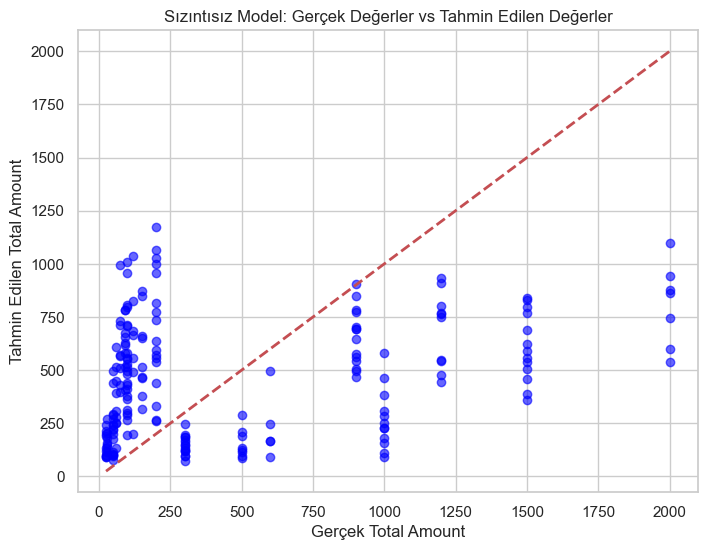

In [10]:
# Gerçek Değer vs Tahmin Grafiği
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Sızıntısız Model: Gerçek Değerler vs Tahmin Edilen Değerler')
plt.xlabel('Gerçek Total Amount')
plt.ylabel('Tahmin Edilen Total Amount')
plt.show()

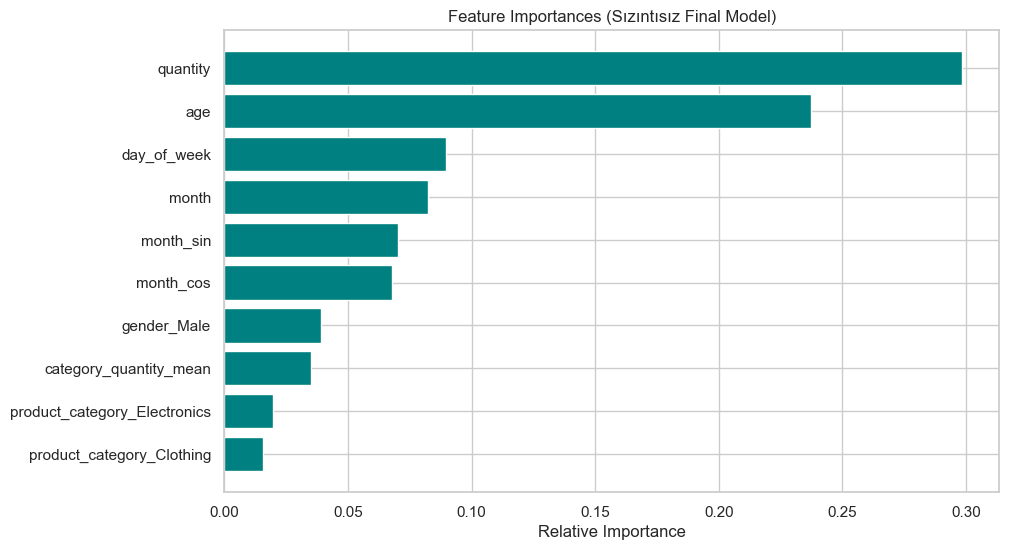

In [11]:
# Feature Importance (Özellik Önemi) Grafiği
importance = rf.feature_importances_
features = X.columns
indices = np.argsort(importance)[-10:] # Sadece en önemli 10 değişken

plt.figure(figsize=(10, 6))
plt.title('Feature Importances (Sızıntısız Final Model)')
plt.barh(range(len(indices)), importance[indices], align='center', color='teal')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

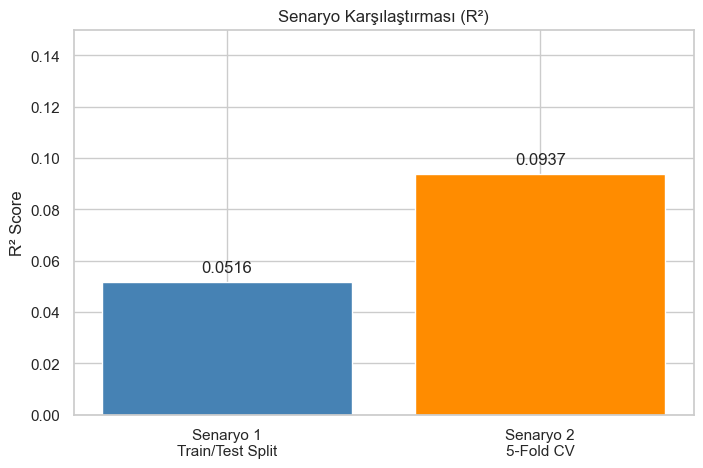

In [12]:
# Senaryo 1 ve Senaryo 2 R2 karşılaştırması
# Değerler src/train_model.py çıktılarından alınmıştır.
scenario_labels = ['Senaryo 1\nTrain/Test Split', 'Senaryo 2\n5-Fold CV']
r2_scores = [0.0516, 0.0937]

plt.figure(figsize=(8, 5))
plt.bar(scenario_labels, r2_scores, color=['steelblue', 'darkorange'])
plt.title('Senaryo Karşılaştırması (R²)')
plt.ylabel('R² Score')
plt.ylim(0, 0.15)

for i, value in enumerate(r2_scores):
    plt.text(i, value + 0.004, f'{value:.4f}', ha='center')

plt.show()

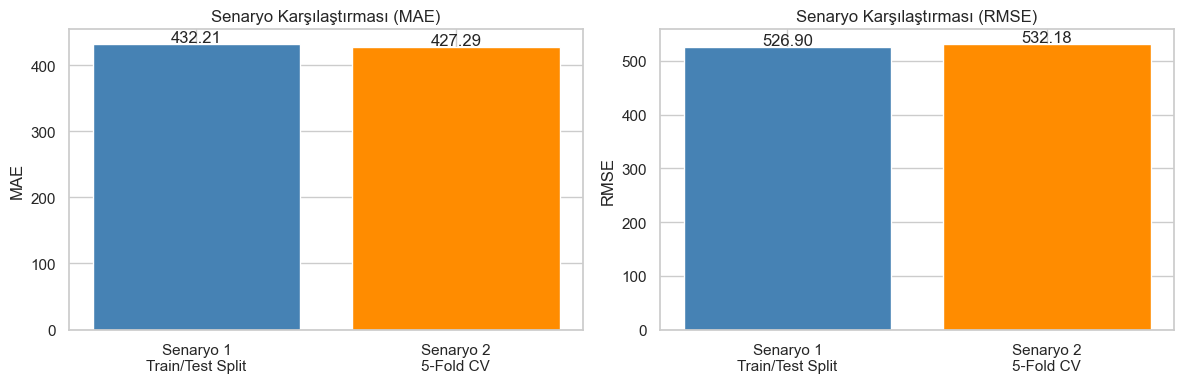

In [13]:
# Senaryo 1 ve Senaryo 2 MAE / RMSE karşılaştırması
# Değerler src/train_model.py çıktılarından alınmıştır.
scenario_labels = ['Senaryo 1\nTrain/Test Split', 'Senaryo 2\n5-Fold CV']
mae_scores = [432.2090, 427.2936]
rmse_scores = [526.9038, 532.1848]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(scenario_labels, mae_scores, color=['steelblue', 'darkorange'])
axes[0].set_title('Senaryo Karşılaştırması (MAE)')
axes[0].set_ylabel('MAE')
for i, value in enumerate(mae_scores):
    axes[0].text(i, value + 3, f'{value:.2f}', ha='center')

axes[1].bar(scenario_labels, rmse_scores, color=['steelblue', 'darkorange'])
axes[1].set_title('Senaryo Karşılaştırması (RMSE)')
axes[1].set_ylabel('RMSE')
for i, value in enumerate(rmse_scores):
    axes[1].text(i, value + 3, f'{value:.2f}', ha='center')

plt.tight_layout()
plt.show()